# Módulo 11 — Búsqueda y emparejamiento: Mortensen–Pissarides y Hosios

**Curso complementario · puremacro · mazo Slides08 — mercados no competitivos: precios rígidos y fricciones laborales (semanas 15–16)**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. Armar el **modelo de Mortensen–Pissarides**: función de emparejamiento,
   **curva de creación de empleo** (entrada libre) y **ecuación de Beveridge**,
   y resolver su estado estacionario.
2. **Simular** la curva de Beveridge *del modelo* — el lugar geométrico
   decreciente $u$–$v$ que emerge del balance de flujos — con choques de
   productividad.
3. Reproducir el **puzzle de Shimer**: con calibración estándar la tensión
   $\theta$ apenas reacciona a la productividad (elasticidad $\approx 1.8$ en
   esta calibración, el mismo orden que el $1.7$ de Shimer 2005), lejos de la
   amplificación de los datos ($15$–$20$ en la literatura; $\approx 25$ en la
   muestra JOLTS 2001–hoy que mide esta lección y también el mazo).
4. Derivar la **condición de Hosios**: el bienestar se maximiza cuando el
   poder de negociación del trabajador iguala la **elasticidad del matching**
   ($\eta=\alpha$ aquí, $\gamma=\phi$ en el mazo: ver el puente de notación de
   abajo), y leer las **externalidades** de congestión que lo explican.

Esta es una lección **analítica/de simulación**: todo el modelo corre en
Python puro sobre tu **instalación local** de `puremacro`
(`pip install puremacro`), $0. Solo el puzzle de Shimer contrasta contra
datos ya congelados en el bundle.

### Puente de notación con el mazo Slides08 (léelo antes de la sección 1)

El código de esta lección usa los nombres de parámetro de
`puremacro.models.DMPParameters` —que son los de la literatura de búsqueda— y
**no** los símbolos que la lámina de notación del mazo Slides08 reserva. No los
renombramos porque el código se verifica dígito a dígito contra esa API, pero la
traducción es obligatoria:

| símbolo del mazo | símbolo/nombre aquí | qué es |
|---|---|---|
| $\phi$ | $\alpha$ (`alpha`) | elasticidad del emparejamiento respecto del **desempleo** |
| $\gamma$ | $\eta$ (`eta`) | poder de negociación del trabajador |
| $\kappa$ | $c$ (`c`) | costo de publicar una vacante |
| $b$ | $z$ (`z`) | valor del ocio del no empleado |

**Aviso de colisión, el más caro:** en el mazo (y en la lección 10b, del mazo
Slides07) $\alpha$ es la **participación del capital** ($\alpha=0.32$). Aquí
$\alpha$ es la elasticidad del emparejamiento ($\alpha=0.5$). Son dos cosas
distintas y conviven en el bloque final del curso.

Y un desfase que también hay que declarar: el mazo escribe la entrada libre como
$\kappa/q(\theta)=J$ y esta lección como $c=\beta\,q(\theta)\,J$. Difieren en un
factor $\beta$ porque aquí la vacante se paga **hoy** y el puesto empieza a
producir **mañana** (fechado en tiempo discreto); en el límite de tiempo continuo
del mazo, $\beta\to1$ y las dos condiciones coinciden.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib
try:  # bajo Jupyter/ipykernel: conserva el backend inline (captura figuras)
    get_ipython()
except NameError:
    matplotlib.use("Agg")  # script plano / CLI: backend no interactivo
import matplotlib.pyplot as plt
_cwd = pathlib.Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd.parent
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor
DATA = (_nb / "course" / "data")

In [2]:
# --- El modelo MP en NumPy puro (transparente, sin dependencias externas) ---
# Emparejamiento Cobb-Douglas  M = mu * u^alpha * v^(1-alpha)
#   q(theta) = M/v = mu * theta^(-alpha)     (tasa de llenado de vacante)
#   f(theta) = M/u = mu * theta^(1-alpha)     (tasa de hallazgo de empleo)
# Valor de un puesto lleno:   J = (y - w) + beta (1-s) J   ->  J = (y-w)/(1-beta(1-s))
# Entrada libre (creacion de empleo):   c = beta * q(theta) * J
# Salario Nash:   w = (1-eta) z + eta (y + c theta)     (eta = poder del trabajador)
# El residuo de entrada libre es MONOTONO CRECIENTE en theta (q baja, w sube, J baja),
# asi que una biseccion basta -> sin scipy, una dependencia menos que instalar.
def solve_theta(y, mu=1.0, alpha=0.5, beta=0.99, s=0.10, z=0.40, c=0.20, eta=0.5):
    """Tensión de equilibrio theta=v/u por entrada libre (bisección pura)."""
    def resid(th):
        w = (1.0 - eta) * z + eta * (y + c * th)
        J = (y - w) / (1.0 - beta * (1.0 - s))
        return c - beta * (mu * th ** (-alpha)) * J
    lo, hi = 1e-6, 1e3
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if resid(mid) > 0.0:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


def mp_steady_state(y=1.0, **kw):
    """Estado estacionario MP: theta, tasa de hallazgo f, desempleo u, vacantes v, salario w."""
    th = solve_theta(y, **kw)
    mu = kw.get("mu", 1.0); alpha = kw.get("alpha", 0.5)
    s = kw.get("s", 0.10); z = kw.get("z", 0.40); c = kw.get("c", 0.20)
    eta = kw.get("eta", 0.5)
    f = mu * th ** (1.0 - alpha)          # hallazgo
    u = s / (s + f)                        # Beveridge: entradas s(1-u) = salidas f u
    v = th * u
    w = (1.0 - eta) * z + eta * (y + c * th)
    return dict(theta=th, f=f, u=u, v=v, w=w)


# Lector uniforme para los CSV congelados del bundle (formato FRED). Siempre
# desde disco — nunca por red — para que corra idéntico en cualquier instalación.
def load_series(name: str) -> pd.Series:
    df = pd.read_csv(DATA / f"{name}.csv")
    df.columns = ["date", name]
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date")[name]

## 1. El modelo de Mortensen–Pissarides

Un mercado laboral con **fricciones de búsqueda**: contratar toma tiempo y
recursos. Tres bloques cierran el modelo.

**(i) Función de emparejamiento.** Los encuentros entre $u$ buscadores y $v$
vacantes son
$$ M(u,v) = \mu\, u^{\alpha}\, v^{1-\alpha}, \qquad \theta \equiv \frac{v}{u}. $$
De ahí la tasa de **hallazgo** $f(\theta)=M/u=\mu\,\theta^{1-\alpha}$ y la de
**llenado** $q(\theta)=M/v=\mu\,\theta^{-\alpha}$. El parámetro $\alpha\in(0,1)$
es la **elasticidad del matching** respecto del desempleo — retenlo, será el
protagonista de la sección 3.

**(ii) Creación de empleo (entrada libre).** Una vacante cuesta $c$ por
período y se llena con probabilidad $q(\theta)$. El valor de un puesto lleno es
$J=(y-w)/(1-\beta(1-s))$ (produce $y$, paga $w$, se destruye a tasa $s$). La
entrada de empresas continúa hasta agotar la renta:
$$ \underbrace{c}_{\text{costo}} = \beta\, q(\theta)\, J. $$
Esto fija $\theta$: es la **curva de creación de empleo (JC)**, un rayo
$v=\theta u$ desde el origen. Más productividad $y$ $\Rightarrow$ $J$ mayor
$\Rightarrow$ $\theta$ mayor (rayo más empinado).

**(iii) Ecuación de Beveridge.** En estado estacionario las entradas al
desempleo igualan las salidas, $s(1-u)=f(\theta)\,u$, de donde
$$ u = \frac{s}{s+f(\theta)}, \qquad v = \Big[\tfrac{s(1-u)}{\mu\,u^{\alpha}}\Big]^{1/(1-\alpha)}. $$
Es la **curva de Beveridge (BC)**: decreciente en el plano $(u,v)$. El salario
se fija por **negociación de Nash**, $w=(1-\eta)z+\eta\,(y+c\theta)$, donde
$\eta$ es el poder del trabajador y $z$ su valor de no trabajar.

### La calibración: **trimestral**, la misma del `.mod` del curso
El período es un **trimestre**, no un mes: $\beta=0.99$ y $s=0.10$ son
exactamente los valores del archivo `modelos/merz_andolfatto.mod` del curso
(`beta = 0.99` descuento, `s = 0.10` *tasa de separación trimestral*,
`phi = 0.50` elasticidad del matching). Léelo así antes de mirar los números:
$f(\theta)$ es una **tasa de flujo por trimestre**, no una probabilidad, y por
eso puede pasar de 1: $f=1.63$ trimestral equivale a $\approx 0.54$ mensual, o
sea una probabilidad mensual de encontrar empleo de $1-e^{-0.54}\approx 0.42$
—muy cerca del $0.45$ que reporta Shimer para EE.UU.—. Con $s=0.10$ y
$f=1.63$ el desempleo de estado estacionario sale $5.8\%$, también realista.
El único parámetro que no coincide con el `.mod` es el costo de la vacante
($c=0.20$ aquí, $\kappa=0.30$ allá): es una normalización distinta del mismo
objeto, y ninguno de los resultados de abajo depende de ella.

In [3]:
# Calibración estándar TRIMESTRAL (la del .mod del curso: beta=0.99, s=0.10, phi=alpha=0.5).
CAL = dict(mu=1.0, alpha=0.5, beta=0.99, s=0.10, z=0.40, c=0.20, eta=0.5)
ss = mp_steady_state(y=1.0, **CAL)
print("estado estacionario MP (calibración base, período = trimestre):")
print(f"  tensión   theta = v/u   = {ss['theta']:.3f}")
print(f"  hallazgo  f(theta)       = {ss['f']:.3f}   (tasa de flujo por trimestre)")
print(f"  llenado   q(theta)       = {CAL['mu']*ss['theta']**(-CAL['alpha']):.3f}   (probabilidad de llenar la vacante)")
print(f"  desempleo u              = {ss['u']*100:.2f}%")
print(f"  vacantes  v              = {ss['v']:.3f}")
print(f"  salario   w              = {ss['w']:.3f}  (producto y = 1.000)")

# Verificación cruzada: el mismo estado estacionario con el solver estructural
# del paquete, puremacro.models.dmp_steady_state (sigma=0 -> MP puro, sin el
# canal de incertidumbre por régimen). Debe coincidir dígito a dígito.
from puremacro.models import DMPParameters, dmp_steady_state
p = DMPParameters(beta_bar=CAL["beta"], alpha=CAL["alpha"], eta_b=CAL["eta"],
                  s=CAL["s"], z=CAL["z"], y_bar=1.0, c=CAL["c"], mu=CAL["mu"],
                  eta=0.0, kappa=0.0)
d = dmp_steady_state(p, sigma=0.0, regime="H")
print(f"\npuremacro.models.dmp_steady_state: theta={d.theta:.3f}, u={d.u*100:.2f}%, v={d.v:.3f}")
assert abs(d.theta - ss["theta"]) < 1e-6 and abs(d.u - ss["u"]) < 1e-6

estado estacionario MP (calibración base, período = trimestre):
  tensión   theta = v/u   = 2.642
  hallazgo  f(theta)       = 1.625   (tasa de flujo por trimestre)
  llenado   q(theta)       = 0.615   (probabilidad de llenar la vacante)
  desempleo u              = 5.80%
  vacantes  v              = 0.153
  salario   w              = 0.964  (producto y = 1.000)



puremacro.models.dmp_steady_state: theta=2.642, u=5.80%, v=0.153


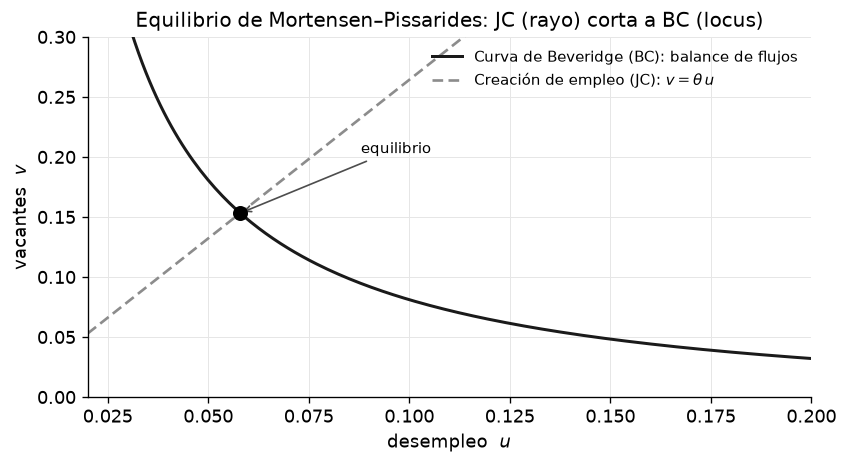

In [4]:
# --- Diagrama JC x BC: el equilibrio es la intersección ---
ug = np.linspace(0.02, 0.20, 200)
vg_BC = (CAL["s"] * (1 - ug) / (CAL["mu"] * ug ** CAL["alpha"])) ** (1.0 / (1 - CAL["alpha"]))
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(ug, vg_BC, color="0.10", lw=1.8, label="Curva de Beveridge (BC): balance de flujos")
ax.plot(ug, ss["theta"] * ug, color="0.55", lw=1.6, ls=(0, (4, 2)),
        label=r"Creación de empleo (JC): $v=\theta\,u$")
ax.plot(ss["u"], ss["v"], "o", color="0.0", ms=8, zorder=5)
ax.annotate("equilibrio", (ss["u"], ss["v"]), xytext=(ss["u"] + 0.03, ss["v"] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle="->", color="0.3"))
ax.set_xlabel("desempleo  $u$"); ax.set_ylabel("vacantes  $v$")
ax.set_title("Equilibrio de Mortensen–Pissarides: JC (rayo) corta a BC (locus)")
ax.set_xlim(0.02, 0.20); ax.set_ylim(0, 0.30)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

### Simulando la curva de Beveridge *del modelo*
La BC dibujada arriba es el *locus* teórico. Ahora dejemos que el modelo la
**trace por sí mismo**: alimentamos una productividad $\log y_t$ AR(1) y, en
cada período, la tensión $\theta_t$ **salta** al valor de entrada libre
(variable de brinco), mientras el desempleo se ajusta **despacio** por su ley
de movimiento $u_{t+1}=u_t+s(1-u_t)-f(\theta_t)\,u_t$. Como $v_t=\theta_t u_t$
reacciona al instante y $u_t$ se arrastra, la nube $(u,v)$ recorre la BC en
**bucles antihorarios** — exactamente el patrón que muestran los datos de
JOLTS.

In [5]:
rng = np.random.default_rng(20260721)   # sin datos externos: productividad simulada, declarada
T, rho, sig = 500, 0.95, 0.012
ly = np.zeros(T)
for t in range(1, T):
    ly[t] = rho * ly[t - 1] + sig * rng.standard_normal()
yv = np.exp(ly)                          # nivel de productividad

u = np.full(T, ss["u"]); v = np.zeros(T); th = np.zeros(T)
for t in range(T):
    th[t] = solve_theta(yv[t], **CAL)    # theta salta (variable forward)
    v[t] = th[t] * u[t]
    if t + 1 < T:
        f = CAL["mu"] * th[t] ** (1 - CAL["alpha"])
        u[t + 1] = u[t] + CAL["s"] * (1 - u[t]) - f * u[t]   # u se arrastra
burn = 100
uu, vv = u[burn:], v[burn:]
rho_uv = np.corrcoef(uu, vv)[0, 1]
rho_lead = np.corrcoef(vv[:-1], uu[1:])[0, 1]     # v de hoy contra u de mañana
# Área con signo del sendero (u,v) estandarizado: > 0 <=> bucles ANTIHORARIOS.
xs = (uu - uu.mean()) / uu.std(); ys = (vv - vv.mean()) / vv.std()
area = 0.5 * np.sum(xs[:-1] * ys[1:] - xs[1:] * ys[:-1])
print(f"simulación: {len(uu)} períodos tras calentamiento")
print(f"corr(u_t, v_t) en la simulación   = {rho_uv:.2f}   (< 0  ->  pendiente de Beveridge)")
print(f"corr(v_t, u_[t+1])                = {rho_lead:.2f}   (las vacantes anticipan al desempleo)")
print(f"área con signo del sendero        = {area:+.1f}   (> 0  ->  bucles ANTIHORARIOS)")
assert rho_uv < -0.3, "la nube simulada debe ser decreciente (curva de Beveridge)"
assert area > 0, "los bucles deben recorrerse en sentido antihorario"

simulación: 400 períodos tras calentamiento
corr(u_t, v_t) en la simulación   = -0.63   (< 0  ->  pendiente de Beveridge)
corr(v_t, u_[t+1])                = -1.00   (las vacantes anticipan al desempleo)
área con signo del sendero        = +29.9   (> 0  ->  bucles ANTIHORARIOS)


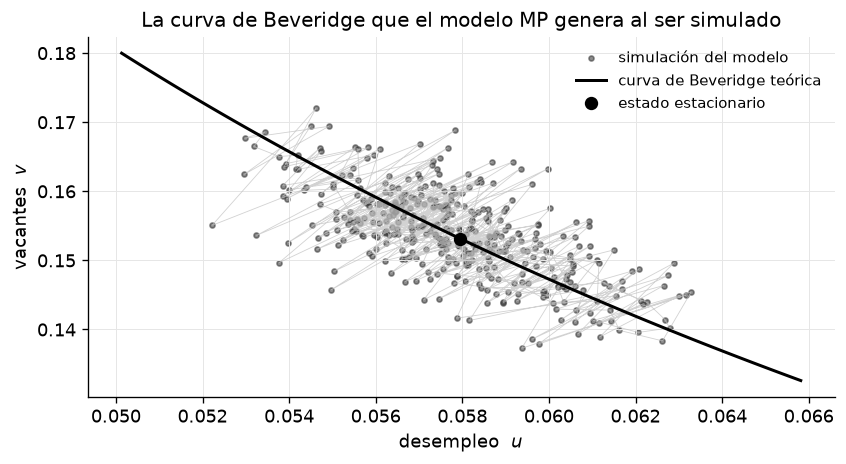

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(uu, vv, "-", color="0.75", lw=0.5, alpha=0.7)          # sendero (bucles)
ax.scatter(uu, vv, s=9, color="0.25", alpha=0.6, label="simulación del modelo")
ub = np.linspace(uu.min() * 0.96, uu.max() * 1.04, 120)
vb = (CAL["s"] * (1 - ub) / (CAL["mu"] * ub ** CAL["alpha"])) ** (1.0 / (1 - CAL["alpha"]))
ax.plot(ub, vb, color="0.0", lw=1.8, label="curva de Beveridge teórica")
ax.plot(ss["u"], ss["v"], "o", color="0.0", ms=7, zorder=5, label="estado estacionario")
ax.set_xlabel("desempleo  $u$"); ax.set_ylabel("vacantes  $v$")
ax.set_title("La curva de Beveridge que el modelo MP genera al ser simulado")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

**Lectura.** Los puntos simulados se pegan al locus teórico y lo recorren en
bucles **antihorarios**. Ojo al orden, que es lo que produce el bucle: cuando
llega el auge, $u_t$ todavía está **alto** (es un estado, viene de la recesión)
y $v_t=\theta_t u_t$ salta; así que la economía sube **por el lado derecho** del
gráfico y solo después se desliza hacia la **izquierda-arriba** mientras el
desempleo se drena. En la recesión pasa lo simétrico: $u$ todavía está bajo,
$v$ se desploma **por el lado izquierdo**, y luego la economía se desplaza hacia
la **derecha-abajo** a medida que el desempleo se acumula. En la simulación esto
se ve en que $\mathrm{corr}(v_t,u_{t+1})=-1.00$ es más fuerte que la
contemporánea $\mathrm{corr}(v_t,u_t)=-0.63$: las vacantes **anticipan** al
desempleo. Movimientos *a lo largo* de la BC son ciclo de
demanda; para **desplazar** la curva hacia afuera haría falta cambiar un
parámetro estructural — $\mu$ (peor emparejamiento) o $s$ (más separaciones) —,
la lectura estructural del corrimiento post-COVID de la curva de Beveridge.

## 2. El puzzle de Shimer

El modelo MP hace una predicción cuantitativa nítida: la **elasticidad** de la
tensión respecto de la productividad, $\mathrm{d}\log\theta/\mathrm{d}\log y$,
es de **orden 1** (aquí saldrá **1.77**). Intuición: la renta de un puesto es
$y-w$, pero con Nash el salario **absorbe** casi todo el aumento de $y$
($w=(1-\eta)z+\eta(y+c\theta)$), así que la renta $J$ se mueve poco y la entrada
de vacantes apenas responde.

En los datos, en cambio, $\theta$ es **un orden de magnitud** más volátil que la
productividad: la literatura cita **15–20** (Shimer 2005 obtiene $\approx 20$
para 1951–2003) y la muestra JOLTS que medimos abajo da $\approx 25$ —la misma
cifra que el ejercicio insignia del mazo Slides08—. El modelo estándar,
calibrado a lo razonable, genera **1.8** (Shimer obtiene 1.7 con la suya): eso
es el **puzzle** de la falta de amplificación.

In [7]:
def theta_elasticity(z, dy=0.01, **kw):
    """Elasticidad d log theta / d log y por perturbación numérica."""
    base = dict(CAL); base.update(kw); base["z"] = z
    t0 = solve_theta(1.0, **base); t1 = solve_theta(1.0 + dy, **base)
    return (np.log(t1) - np.log(t0)) / np.log(1.0 + dy)

el_std = theta_elasticity(z=0.40)     # outside option bajo (Shimer)
el_hm  = theta_elasticity(z=0.955)    # excedente fundamental pequeño (Hagedorn–Manovskii)
print(f"elasticidad d log theta / d log y — calibración estándar (z=0.40): {el_std:.2f}")
print(f"elasticidad d log theta / d log y — Hagedorn–Manovskii  (z=0.955): {el_hm:.2f}")
print("  como theta es variable de brinco y función estática de y, se cumple")
print("  sd(log theta) = elasticidad x sd(log y): la elasticidad ES el cociente")
print("  de amplitudes que el modelo predice.")
# Advertencia de nivel: subir SOLO z (sin bajar eta, como sí hacen HM) amplifica,
# pero deja un estado estacionario poco creíble. Lo declaramos en vez de esconderlo.
ss_hm = mp_steady_state(y=1.0, **{**CAL, "z": 0.955})
print(f"  ojo: con z=0.955 y eta=0.5 el estado estacionario es theta={ss_hm['theta']:.2f},"
      f" u={ss_hm['u']*100:.1f}%")
el_hm_full = theta_elasticity(z=0.955, eta=0.052)   # HM también bajan el poder del trabajador
print(f"  (HM además bajan el poder de negociación a gamma=0.052: con esa pieza el")
print(f"   estado estacionario vuelve a u={mp_steady_state(y=1.0, **{**CAL, 'z': 0.955, 'eta': 0.052})['u']*100:.1f}%"
      f" y la elasticidad sube a {el_hm_full:.1f}.")
print("   El ejercicio de abajo compara ELASTICIDADES, no niveles de desempleo)")
assert el_std < 5.0, "la calibración estándar NO amplifica (ahí está el puzzle)"
assert el_hm > 10.0, "el excedente fundamental pequeño SÍ amplifica"

elasticidad d log theta / d log y — calibración estándar (z=0.40): 1.77
elasticidad d log theta / d log y — Hagedorn–Manovskii  (z=0.955): 24.52
  como theta es variable de brinco y función estática de y, se cumple
  sd(log theta) = elasticidad x sd(log y): la elasticidad ES el cociente
  de amplitudes que el modelo predice.
  ojo: con z=0.955 y eta=0.5 el estado estacionario es theta=0.14, u=21.0%
  (HM además bajan el poder de negociación a gamma=0.052: con esa pieza el
   estado estacionario vuelve a u=7.5% y la elasticidad sube a 29.1.
   El ejercicio de abajo compara ELASTICIDADES, no niveles de desempleo)


### Ficha de medición del segundo momento (regla del curso: seis campos)
El cociente $sd(\log\theta)/sd(\log A)$ es un segundo momento, así que no se
publica sin declarar cómo se midió:

| campo | valor |
|---|---|
| **fuente / serie** | FRED, CSV congelados en `course/data/`: `JTSJOL` (vacantes, miles), `UNEMPLOY` (desempleados, miles) y `OPHNFB` (producto por hora, sector no agrícola de negocios, índice 2017=100). Son las tres series del ejercicio insignia del mazo Slides08 |
| **muestra** | 2001Q1–2026Q1 (101 trimestres); JOLTS arranca en dic-2000, se descarta ese trimestre incompleto |
| **filtro** | HP con $\lambda=1600$ sobre logs, la convención trimestral del curso (Shimer usó $\lambda=10^{5}$; el mazo pide discutir la sensibilidad, también con Hamilton) |
| **base de precios** | no aplica precios de gasto: $\theta$ es un cociente de conteos de personas y $A$ es un índice de volumen (producto por hora) con base 2017=100 |
| **orden recortar–filtrar** | mensual $\to$ trimestral por promedio simple, **recortar** a la muestra común y **después** filtrar (nunca al revés) |
| **edición / vintage** | último dato congelado del bundle: JOLTS hasta may-2026, OPHNFB hasta 2026Q1; sin revisiones posteriores |

Ojo con la muestra: es **corta y contiene la COVID**. El cociente sale $24.9$;
excluyendo 2020 en adelante baja apenas a $24.8$, así que el resultado no es un
artefacto del choque pandémico. (La misma cifra que el mazo Slides08 reporta
como «25 en la muestra 2001–hoy de JOLTS».)

In [8]:
# Contraste empírico con datos ya congelados del bundle (nunca por red):
# tensión theta = vacantes JOLTS / desempleados (ambos en miles de personas,
# igual que el ejercicio insignia del mazo), productividad OPHNFB.
from puremacro.data import hp_filter          # (cycle, trend) = hp_filter(y, lamb=1600)

V = load_series("JTSJOL"); U_lvl = load_series("UNEMPLOY"); prod = load_series("OPHNFB")
theta_m = (V / U_lvl).dropna()
theta_m = theta_m[theta_m.index >= pd.Timestamp("2001-01-01")]   # dic-2000 = trimestre incompleto
theta_q = theta_m.resample("QS").mean()
prod_q = prod.resample("QS").mean().dropna()
idx = theta_q.index.intersection(prod_q.index)                   # recortar ANTES de filtrar
c_theta, _ = hp_filter(np.log(theta_q.loc[idx].to_numpy()))      # ciclo HP, lambda=1600
c_A, _ = hp_filter(np.log(prod_q.loc[idx].to_numpy()))
c_theta, c_A = np.asarray(c_theta), np.asarray(c_A)
ratio_data = c_theta.std() / c_A.std()
print(f"muestra: {idx.min():%YQ}{idx.min().quarter}–{idx.max():%YQ}{idx.max().quarter}"
      f"  ({len(idx)} trimestres)")
print(f"datos EE.UU.: sd(ciclo log theta) / sd(ciclo log A) = {ratio_data:.1f}")
pre = idx < pd.Timestamp("2020-01-01")
print(f"  robustez, excluyendo la COVID (hasta 2019Q4): {c_theta[pre].std()/c_A[pre].std():.1f}")
assert ratio_data > 5.0

muestra: 2001Q1–2026Q1  (101 trimestres)
datos EE.UU.: sd(ciclo log theta) / sd(ciclo log A) = 24.9
  robustez, excluyendo la COVID (hasta 2019Q4): 24.8


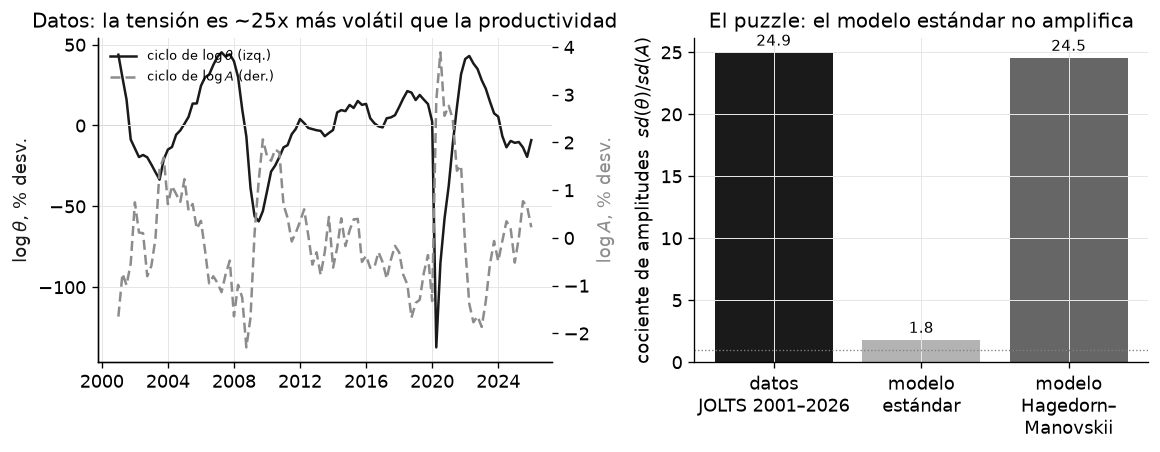

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))
qd = pd.PeriodIndex(pd.DatetimeIndex(idx), freq="Q").to_timestamp()
ax = axes[0]
ax.plot(qd, 100 * c_theta, color="0.10", lw=1.5, label=r"ciclo de $\log\theta$ (izq.)")
ax.set_ylabel(r"$\log\theta$, % desv.", color="0.10"); ax.axhline(0, color="0.85", lw=0.6)
ax2 = ax.twinx()
ax2.plot(qd, 100 * c_A, color="0.55", lw=1.5, ls=(0, (4, 2)), label=r"ciclo de $\log A$ (der.)")
ax2.set_ylabel(r"$\log A$, % desv.", color="0.55"); ax2.grid(False)
ax.set_title(f"Datos: la tensión es ~{ratio_data:.0f}x más volátil que la productividad")
lines = ax.get_lines()[:1] + ax2.get_lines()[:1]
ax.legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=8)

ax = axes[1]
labels = ["datos\nJOLTS 2001–2026", "modelo\nestándar", "modelo\nHagedorn–\nManovskii"]
vals = [ratio_data, el_std, el_hm]
ax.bar(labels, vals, color=["0.10", "0.70", "0.40"])
for i, val in enumerate(vals):
    ax.text(i, val + 0.6, f"{val:.1f}", ha="center", fontsize=9)
ax.axhline(1.0, color="0.5", lw=0.8, ls=":")
ax.set_ylabel(r"cociente de amplitudes  $sd(\theta)/sd(A)$")
ax.set_title("El puzzle: el modelo estándar no amplifica")
plt.tight_layout(); plt.show()

**La resolución de Hagedorn–Manovskii (2008).** Si el valor de no trabajar $z$
está **cerca** de la productividad $y$, el *excedente fundamental* $y-z$ se
vuelve diminuto: un choque pequeño de $y$ es enorme **en proporción** al
excedente, así que $J$ y $\theta$ estallan y la elasticidad salta de **1.8** a
**24.5** (barra derecha) — cerrando el puzzle. Con la salvedad de nivel que ya
imprimimos: subir solo $z$ deja $u=21.0\%$ en estado estacionario; HM recuperan
el nivel bajando además el poder de negociación a $\gamma=0.052$, y con esa
pieza el desempleo vuelve a $7.5\%$ y la elasticidad sube a $29.1$. La ruta
alternativa (Hall
2005) es **rigidez salarial**: si $w$ responde poco al choque, la renta $y-w$
absorbe casi todo el impulso y las vacantes se disparan. `puremacro` trae ambos
canales en `puremacro.models.dmp_irf` — la regla de salario pegajoso de Hall
(parámetro `psi`) y el excedente vía `z`.

## 3. Eficiencia: la condición de Hosios

¿El equilibrio descentralizado crea la cantidad **correcta** de vacantes? No en
general: hay dos **externalidades de congestión** que las empresas no
internalizan al postear una vacante más.
- **Externalidad de aglomeración** (positiva, sobre los buscadores): una
  vacante extra sube la tasa de hallazgo $f(\theta)$ de todo desempleado.
- **Externalidad de congestión** (negativa, sobre otras empresas): esa misma
  vacante baja la tasa de llenado $q(\theta)$ de las demás.

La elasticidad del matching $\alpha$ mide el peso relativo de ambas. **Hosios
(1990):** el equilibrio es **eficiente** exactamente cuando el poder de
negociación del trabajador iguala esa elasticidad,
$$ \boxed{\;\eta = \alpha\;} $$
— que es la misma condición que el mazo Slides08 escribe $\gamma=\phi$ (ver el
puente de notación del inicio: $\eta\leftrightarrow\gamma$, $\alpha\leftrightarrow\phi$).
Si $\eta<\alpha$, el trabajador captura muy poco, las empresas sobre-postean
vacantes ($\theta$ demasiado alto); si $\eta>\alpha$, ocurre lo contrario.

In [10]:
# Bienestar de flujo del estado estacionario: producto de los ocupados + valor de
# no trabajar de los desempleados - costo de postear vacantes.
#   W(eta) = (1-u) y + u z - c v
# El planificador social elige theta (vía v) para maximizarlo; el mercado con
# poder eta lo replica solo si eta = alpha. Barremos eta y localizamos el óptimo.
def welfare(eta, y=1.0, **kw):
    base = dict(CAL); base.update(kw); base["eta"] = eta
    r = mp_steady_state(y=y, **base)
    return (1 - r["u"]) * y + r["u"] * base["z"] - base["c"] * r["v"]

etas = np.linspace(0.03, 0.97, 471)
W = np.array([welfare(e) for e in etas])
theta_eta = np.array([solve_theta(1.0, **{**CAL, "eta": e}) for e in etas])
i = int(np.argmax(W))
eta_star = etas[i]
theta_eff = solve_theta(1.0, **{**CAL, "eta": CAL["alpha"]})   # tensión eficiente
print(f"poder que MAXIMIZA el bienestar:  eta* = {eta_star:.3f}  (malla de {len(etas)} puntos)")
print(f"elasticidad del matching:         alpha = {CAL['alpha']:.3f}")
print(f"condición de Hosios  eta = alpha:  se cumple  (|eta* - alpha| = {abs(eta_star-CAL['alpha']):.3f})")
print(f"tensión eficiente theta(eta=alpha) = {theta_eff:.3f}")
assert abs(eta_star - CAL["alpha"]) < 0.02, "el óptimo debe caer en eta = alpha (Hosios)"

# ¿Por qué el óptimo no cae EXACTAMENTE en alpha? Porque aquí maximizamos el
# bienestar de FLUJO del estado estacionario y no el problema dinámico del
# planificador: con beta<1 el descuento mete una cuña pequeñísima. Se ve dejando
# que beta -> 1, donde el argmax converge a alpha = 0.5 al cuarto decimal.
etas_fine = np.linspace(0.45, 0.55, 2001)
for b in (CAL["beta"], 0.999, 0.9999):
    Wb = np.array([welfare(e, beta=b) for e in etas_fine])
    print(f"  malla fina, beta={b:<7}:  argmax_eta W = {etas_fine[int(np.argmax(Wb))]:.4f}")

poder que MAXIMIZA el bienestar:  eta* = 0.498  (malla de 471 puntos)
elasticidad del matching:         alpha = 0.500
condición de Hosios  eta = alpha:  se cumple  (|eta* - alpha| = 0.002)
tensión eficiente theta(eta=alpha) = 2.642


  malla fina, beta=0.99   :  argmax_eta W = 0.4971


  malla fina, beta=0.999  :  argmax_eta W = 0.4997


  malla fina, beta=0.9999 :  argmax_eta W = 0.5000


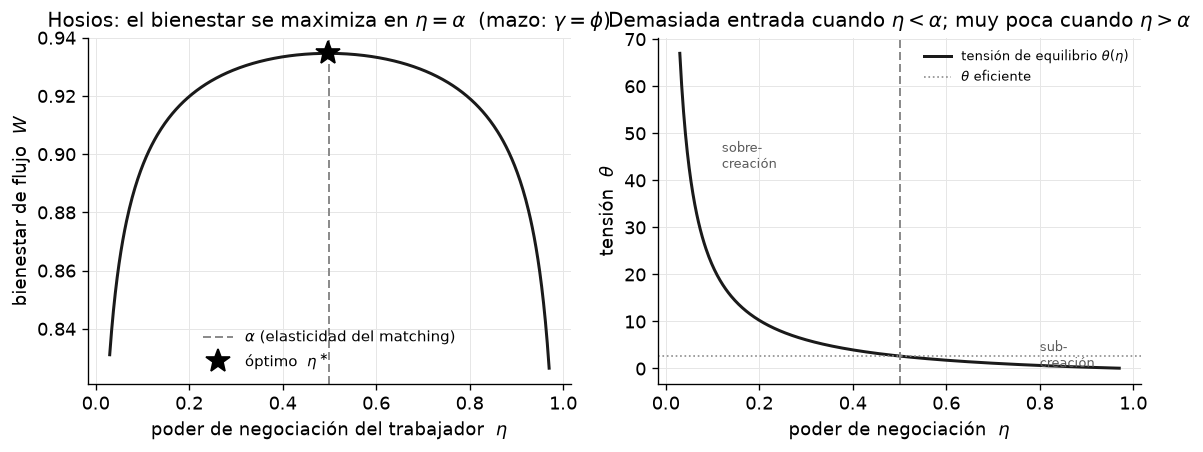

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))
ax = axes[0]
ax.plot(etas, W, color="0.10", lw=1.8)
ax.axvline(CAL["alpha"], color="0.55", lw=1.2, ls=(0, (4, 2)),
           label=r"$\alpha$ (elasticidad del matching)")
ax.plot(eta_star, W[i], "*", color="0.0", ms=15, zorder=5,
        label=r"óptimo  $\eta^\ast$")
ax.set_xlabel(r"poder de negociación del trabajador  $\eta$")
ax.set_ylabel("bienestar de flujo  $W$")
ax.set_title("Hosios: el bienestar se maximiza en $\\eta=\\alpha$  (mazo: $\\gamma=\\phi$)")
ax.legend(loc="lower center", fontsize=9)

ax = axes[1]
ax.plot(etas, theta_eta, color="0.10", lw=1.8, label=r"tensión de equilibrio $\theta(\eta)$")
ax.axhline(theta_eff, color="0.55", lw=1.0, ls=":", label=r"$\theta$ eficiente")
ax.axvline(CAL["alpha"], color="0.55", lw=1.2, ls=(0, (4, 2)))
ax.annotate("sobre-\ncreación", (0.12, theta_eta[10]), fontsize=8, color="0.35")
ax.annotate("sub-\ncreación", (0.80, theta_eta[-40]), fontsize=8, color="0.35")
ax.set_xlabel(r"poder de negociación  $\eta$"); ax.set_ylabel(r"tensión  $\theta$")
ax.set_title("Demasiada entrada cuando $\\eta<\\alpha$; muy poca cuando $\\eta>\\alpha$")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** El bienestar (panel izquierdo) es una campana que culmina en
$\eta=\alpha$ —hasta la cuña del descuento: el argmax exacto es $0.4971$ con
$\beta=0.99$ y converge a $0.5000$ cuando $\beta\to1$, porque lo que
maximizamos es el bienestar de *flujo* del estado estacionario y no el problema
dinámico completo del planificador—. Ahí el reparto de la renta hace que las empresas internalicen
exactamente el balance entre las dos externalidades. A la izquierda del pico
($\eta<\alpha$) el trabajador recibe muy poco, la renta $J$ es alta y entra
**demasiada** vacante — $\theta$ por encima del nivel eficiente (panel
derecho); a la derecha, el salario se come la renta y entra **muy poca**. Nota
que la campana es **plana** cerca del óptimo: errores moderados de $\eta$
cuestan poco bienestar — pero desviaciones grandes (mercados muy
desregulados o muy rígidos) sí importan.

## 4. Preguntas para pensar
1. **Eficiencia y externalidades.** El equilibrio de búsqueda casi nunca es
   eficiente. Explica con las dos externalidades de congestión por qué un
   mercado con trabajadores **débiles** ($\eta<\alpha$) genera *más* vacantes
   de las óptimas — y por qué eso, contraintuitivamente, es un problema.
2. **Política y Hosios.** Si en tu economía $\eta<\alpha$ (poder de negociación
   bajo), ¿qué instrumento acerca el equilibrio al óptimo: un subsidio a la
   contratación, un impuesto a las vacantes, o un seguro de desempleo más
   generoso (que sube $z$)? ¿Y si $\eta>\alpha$? Ojo: mover $z$ también corre
   la curva JC.
3. **Puzzle vs política.** Hagedorn–Manovskii resuelven el puzzle de Shimer con
   $z$ cerca de $y$ (excedente fundamental diminuto). Pero con ese $z$, ¿qué le
   pasa a la sensibilidad del desempleo ante políticas que tocan $z$ (seguro de
   desempleo)? ¿Por qué "resolver el puzzle" y "hacer política de $z$" están en
   tensión?
4. **Beveridge estructural.** En la simulación, ¿qué parámetro tendrías que
   chocar para **desplazar** la curva de Beveridge hacia afuera (no solo
   moverte a lo largo de ella)? Relaciónalo con el debate de "desajuste"
   (*mismatch*) posterior a 2010 y a 2021.

### Notas para las preguntas
1. Con $\eta<\alpha$ la empresa se queda con casi toda la renta del
   emparejamiento, así que postear vacantes es muy rentable y entra demasiada.
   El costo social no es el gasto $cv$ en sí, sino la **externalidad de
   congestión**: cada vacante extra baja $q(\theta)$ para todas las demás, y ese
   daño no entra en el cálculo privado. Con $\alpha$ alto (el desempleo pesa
   mucho en el matching) la externalidad negativa domina, y por eso el óptimo
   exige darle al trabajador exactamente $\eta=\alpha$: es el reparto que hace
   que el privado internalice el balance entre las dos externalidades.
2. Si $\eta<\alpha$ hay **sobre**-creación de vacantes: lo que acerca al óptimo
   es un **impuesto a las vacantes** (o eliminar subsidios a la contratación),
   no un subsidio. Si $\eta>\alpha$, la subvención a la contratación es la
   correcta. Subir $z$ es un instrumento sucio: reduce $\theta$ (mueve la JC
   hacia abajo, porque el salario Nash sube) *y* además cambia el bienestar
   directamente por el término $uz$, así que no aísla la corrección de la
   externalidad. La regla: corrige la externalidad con el instrumento que actúa
   sobre el margen que la genera —la entrada de vacantes—, no sobre el ocio.
3. Con $z\to y$ el excedente $y-z$ es diminuto, así que $\theta$ es hipersensible
   a **cualquier** cosa que lo toque, incluida una política de seguro de
   desempleo. La misma calibración que resuelve el puzzle vuelve al modelo
   absurdamente sensible al seguro de desempleo: predice efectos gigantescos
   sobre $u$ de cambios modestos en la generosidad, que los datos no muestran.
   Ésa es la tensión —y es la crítica estándar (Costain–Reiter) a
   Hagedorn–Manovskii: se compra amplificación al precio de una elasticidad de
   política inverosímil.
4. Desplazar la BC hacia afuera requiere tocar la **tecnología de
   emparejamiento** ($\mu$ abajo, o $\alpha$) o la **separación** $s$ arriba:
   con menos eficiencia de emparejamiento, el mismo par $(u,v)$ produce menos
   encuentros y hace falta más de ambos. Moverse *a lo largo* de la BC es lo que
   hace un choque de productividad, que sólo gira la JC. Ese es justo el
   diagnóstico del debate de *mismatch*: si tras 2010 (y tras 2021) la BC se
   desplaza en vez de deslizarse, el problema no es falta de demanda sino
   deterioro de la tecnología de emparejamiento —desajuste sectorial o
   geográfico, cambios en la intensidad de búsqueda—.

## 5. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- "Explica en una frase por qué la negociación de Nash hace que el salario
  absorba el choque de productividad y por eso el modelo MP estándar no amplifica."
- "¿Por qué la condición de Hosios iguala el poder de negociación a la
  elasticidad del matching, y no a cualquier otro número?"

In [12]:
print(tutor("En una frase, ¿qué dice la condición de Hosios y por qué el poder "
            "de negociación eficiente es igual a la elasticidad de la función "
            "de emparejamiento?"))

[tutor sin conexión] No hay ningún motor de LLM local disponible en esta instalación (el tutor es opcional). Puedes instalar uno con `pip install puremacro[local-llm]` más un modelo pequeño (por ejemplo vía Ollama o MLX), o bien usar las indicaciones de la sección «Explora con IA» de esta lección con cualquier asistente de IA.
(motivo: el motor local no está disponible)


**Resumen.** Armamos el modelo de Mortensen–Pissarides desde sus tres piezas
—función de emparejamiento, creación de empleo por entrada libre y ecuación de
Beveridge—, lo **simulamos** para que trazara su propia curva de Beveridge en
bucles antihorarios, reprodujimos el **puzzle de Shimer** (elasticidad $1.8$
frente a $\approx 25$ en los datos JOLTS 2001–2026) y su resolución por
excedente fundamental ($24.5$), y derivamos numéricamente la **condición de
Hosios**: el bienestar culmina cuando el poder de negociación iguala la
elasticidad del matching, $\eta=\alpha$ —el $\gamma=\phi$ del mazo Slides08—.
Todo en `puremacro` (Python puro), verificado contra
`puremacro.models.dmp_steady_state`.

**Cierre del curso.** Ésta es la última lección del calendario (semana 16). El
bloque B2 se prolonga en la lección **electiva 24 — mercado laboral de cuatro
estados (matriz 4×4 F/I/U/N de la ENOE)**, que lleva estas mismas fricciones al
caso mexicano. Si quieres seguir por tu cuenta con la **dinámica y la
amplificación**, ninguna lección del curso las cubre: la vía es
`puremacro.models.dmp_irf`, pero léele la letra chica antes de correrlo. Su
choque es el de **régimen** (`sigma_shock` + `regime`), no un choque directo de
productividad: bajo `regime="L"` la productividad sube en `kappa*sigma` y bajo
`regime="H"` sube el costo de la vacante en `eta*sigma`. Con los parámetros de
esta lección (`eta=0`, `kappa=0`) la IRF sale **idénticamente cero**; para ver
amplificación hay que pedir, por ejemplo,
`DMPParameters(..., kappa=0.01, psi=0.2)` con `regime="L"`. Y el salario
pegajoso de Hall (`psi`) conviene explorarlo con valores **moderados**
($\psi\lesssim0.3$): más arriba, en esta calibración, la iteración de punto fijo
del solver deja de dar respuestas creíbles. El cuaderno `16_regime_girf_es`
—que vive en el repositorio de `puremacro`, **no** en el ZIP del curso— no hace
ese ejercicio, pero discute la versión dependiente del régimen
(`dmp_regime_dependent`, `dmp_irf(..., regime="H")` vs `"L"`) y por qué una IRF
de régimen congelado responde una pregunta distinta.